# Chemical Property Prediction using Machine Learning

This project predicts solubility of chemical compounds using RDKit descriptors and Linear Regression.

In [3]:
!apt-get install -y python3-rdkit

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following additional packages will be installed:
  fonts-freefont-ttf libboost-iostreams1.74.0 libboost-python1.74.0
  libboost-serialization1.74.0 libcoordgen3 libmaeparser1 librdkit1
  python3-numpy rdkit-data
Suggested packages:
  python-numpy-doc python3-dev python3-pytest rdkit-doc
The following NEW packages will be installed:
  fonts-freefont-ttf libboost-iostreams1.74.0 libboost-python1.74.0
  libboost-serialization1.74.0 libcoordgen3 libmaeparser1 librdkit1
  python3-numpy python3-rdkit rdkit-data
0 upgraded, 10 newly installed, 0 to remove and 6 not upgraded.
Need to get 28.0 MB of archives.
After this operation, 136 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/main amd64 fonts-freefont-ttf all 20120503-10build1 [2,388 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/main amd64 libboost-iostreams1.74.0 amd64 1.74.0-14ubuntu3 [245 kB]
Ge

## Step 1: Install Required Libraries

In this step, we install RDKit, which is used for cheminformatics and molecular descriptor calculation.

In [6]:
import sys
# Uninstall any previously installed rdkit versions via pip
!pip uninstall -y rdkit rdkit-pypi
# Install rdkit using pip (the correct package name is 'rdkit')
!pip install rdkit

# After installation, it's often necessary to restart the runtime for rdkit to load correctly.
# If you still encounter issues after running this, please restart your Colab runtime manually (Runtime -> Restart runtime).

from rdkit import Chem
print("RDKit installed successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.7/36.7 MB 45.0 MB/s eta 0:00:00
RDKit installed successfully!


## Step 2: Import Libraries

We import all necessary libraries including pandas for data handling, RDKit for chemical processing, and scikit-learn for machine learning.

In [7]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Descriptors
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


## Step 3: Create Dataset

Here, we create a small sample dataset containing SMILES strings and their corresponding solubility values.

In [8]:
data = pd.DataFrame({
    "smiles": ["CCO", "CC", "CCC", "CCCC", "CCN", "CCCl"],
    "solubility": [-0.77, -0.30, -0.20, -0.10, -0.50, -0.60]
})

data.head()

,smiles,solubility
0,CCO,-0.77
1,CC,-0.30
2,CCC,-0.20
3,CCCC,-0.10
4,CCN,-0.50


Generating 2D structures for all SMILES strings in the DataFrame:
SMILES: CCO


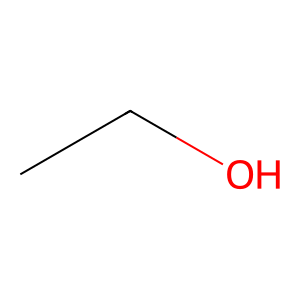

SMILES: CC


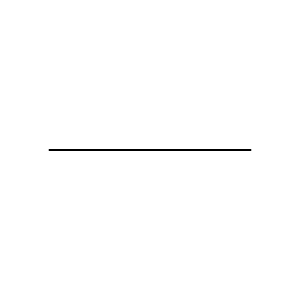

SMILES: CCC


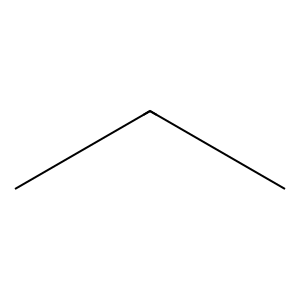

SMILES: CCCC


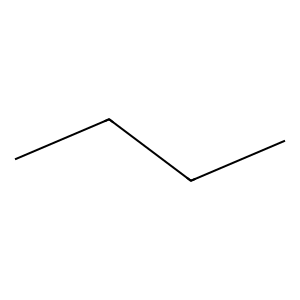

SMILES: CCN


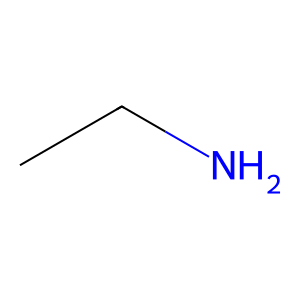

SMILES: CCCl


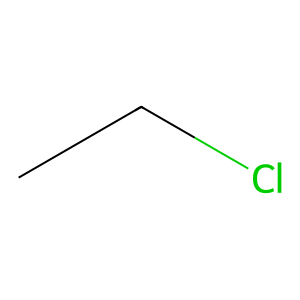

In [9]:
from rdkit.Chem import AllChem
from rdkit.Chem.Draw import MolToImage
from IPython.display import Image

def generate_2d_structure(smiles):
    """Generates and displays a 2D structure from a SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is not None:
        AllChem.Compute2DCoords(mol)
        img = MolToImage(mol)
        # Display the image. In a loop, this will display each image sequentially.
        display(img)
    else:
        print(f"Could not generate molecule from SMILES: {smiles}")

print("Generating 2D structures for all SMILES strings in the DataFrame:")
for index, row in data.iterrows():
    print(f"SMILES: {row['smiles']}")
    generate_2d_structure(row['smiles'])

## Step 4: Feature Engineering

In this step, we convert SMILES strings into numerical features using RDKit. These features include molecular weight, LogP, and hydrogen bond properties.

In [10]:
def calculate_descriptors(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol:
        return [
            Descriptors.MolWt(mol),
            Descriptors.MolLogP(mol),
            Descriptors.NumHDonors(mol),
            Descriptors.NumHAcceptors(mol)
        ]
    else:
        return [None, None, None, None]

features = data["smiles"].apply(calculate_descriptors)

features_df = pd.DataFrame(features.tolist(), columns=[
    "MolWt", "LogP", "HDonors", "HAcceptors"
])

df = pd.concat([features_df, data["solubility"]], axis=1)
df.dropna(inplace=True)

df.head()

,MolWt,LogP,HDonors,HAcceptors,solubility
0,46.069,-0.0014,1,1,-0.77
1,30.070,1.0262,0,0,-0.30
2,44.097,1.4163,0,0,-0.20
3,58.124,1.8064,0,0,-0.10
4,45.085,-0.0350,1,1,-0.50


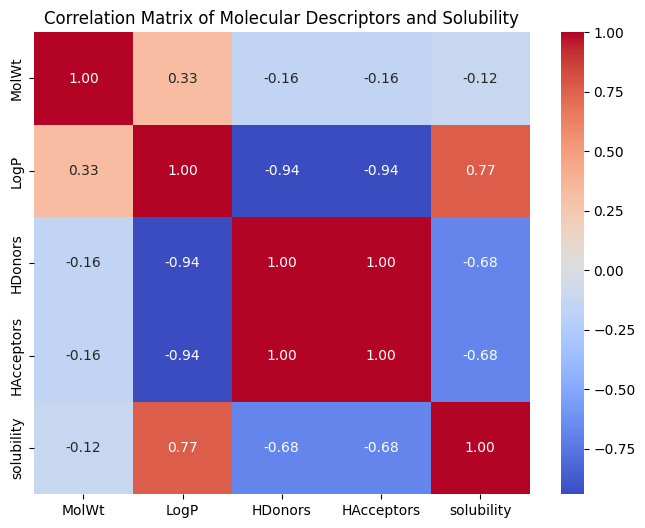

In [17]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Molecular Descriptors and Solubility')
plt.show()

## Step 5: Model Training

We split the dataset into training and testing sets and train a Linear Regression model to learn the relationship between molecular features and solubility.

In [14]:
X = df[["MolWt", "LogP", "HDonors", "HAcceptors"]]
y = df["solubility"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

## Step 6: Model Evaluation

We evaluate the model performance using Mean Squared Error (MSE) and R2 Score to measure prediction accuracy.

In [15]:
y_pred = model.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MSE: 557.2419390136548
R2 Score: -8914.871024218479


## Step 7: Visualization

We plot the actual vs predicted values to visually understand how well the model is performing.

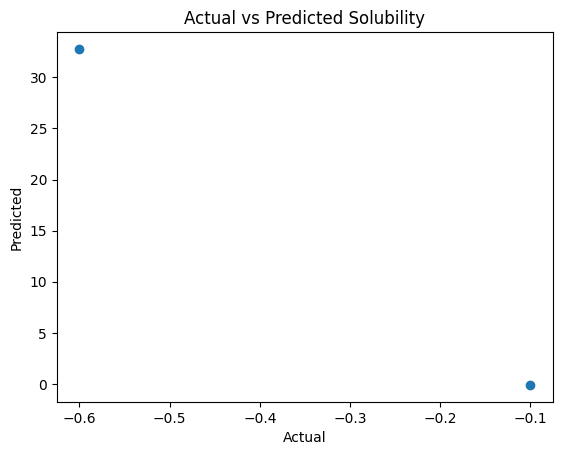

In [16]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted Solubility")
plt.show()

## Step 8: Prediction on New Data

Finally, we test the trained model on a new molecule by converting it into features and predicting its solubility.

In [20]:
new_smiles = "CCO"
new_features = calculate_descriptors(new_smiles)

prediction = model.predict([new_features])
print(f"Predicted solubility: {prediction[0]}")

Predicted solubility: -0.7700000000000076


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


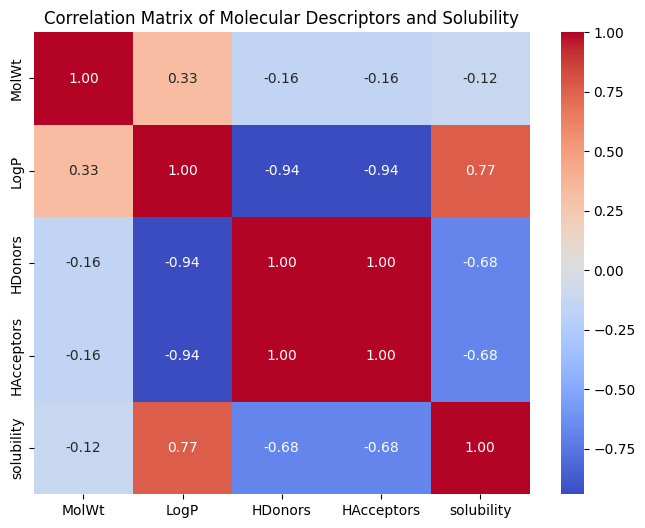

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the correlation matrix
correlation_matrix = df.corr()

# Plotting the heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Molecular Descriptors and Solubility')
plt.show()